# 🌲 Notebook-03: Ensemble-Methoden – Random Forest & XGBoost
**KI Advanced · IA1017000 · HfPolBW**

---

**Session:** S 1.4 – Ensemble-Methoden & ML vertieft
**Ziel:** Random Forest und XGBoost verstehen, vergleichen und auf echte forensische Transaktionsdaten anwenden.
**Dauer:** ~25 Minuten

---

| Teil | Inhalt | Kernfrage |
|------|--------|-----------|
| **1** | Datensatz laden & Feature Engineering | Welche Merkmale einer PayPal-Zahlung sind verdächtig? |
| **2** | Random Forest trainieren | Wie entscheiden 500 Bäume gemeinsam besser als einer? |
| **3** | XGBoost trainieren | Wie lernt jeder neue Baum aus den Fehlern der vorherigen? |
| **4** | Modelle vergleichen | Accuracy, F1, ROC-AUC — was ist der Unterschied? |
| **5** | Feature Importance | Welche Transaktionsmerkmale verraten Streaming-Zahlungen? |
| **6** | 🚔 Challenge: Optimierung | F1 ≥ 0.92 + Modellentscheidung begründen |

---

> ### 📌 Wie benutze ich dieses Notebook?
>
> Jede Code-Zelle ist vollständig kommentiert — lesen, ausführen, beobachten.
>
> **Alles ausführen:** Menü → *Runtime → Run all*

---

> ### 🔗 Verbindung zu S1.2 und S1.3
>
> In S1.2 / NB-01 haben wir den **Entscheidungsbaum** kennengelernt — ein einzelner Baum, erklärbar aber fehleranfällig.
> In S1.3 / NB-02 haben wir das **MLP** verstanden — flexibel aber Black Box.
>
> S1.4 beantwortet die Frage: **Wann schlägt ein Ensemble aus Bäumen ein neuronales Netz?**
> Bei tabellarischen Transaktionsdaten: fast immer — und es ist dabei erklärbarer.


---
## ⚙️ Setup – Bibliotheken laden

Neu in diesem Notebook: `RandomForestClassifier` und `xgboost` — die beiden wichtigsten
Ensemble-Algorithmen für tabellarische Daten. Außerdem `roc_auc_score` und `roc_curve`
für eine differenziertere Modellbewertung als nur Accuracy.


In [1]:
# ─────────────────────────────────────────────────────────────────────────────
# SETUP: Alle benötigten Bibliotheken laden.
# ─────────────────────────────────────────────────────────────────────────────

import numpy as np                          # Mathematik, Zufallszahlen, Arrays
import pandas as pd                         # Tabellen (DataFrames)
import matplotlib.pyplot as plt             # Diagramme
import matplotlib.gridspec as gridspec      # Komplexe Layouts
import warnings; warnings.filterwarnings('ignore')

# ── Ensemble-Algorithmen ──────────────────────────────────────────────────────
from sklearn.ensemble import RandomForestClassifier  # Random Forest (Bagging)
import xgboost as xgb                                # XGBoost (Boosting)

# ── Hilfstools aus sklearn ───────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score,       # Anteil korrekt klassifizierter Datenpunkte
    f1_score,             # Harmonisches Mittel aus Precision und Recall
    precision_score,      # Von allen als Klasse X klassifizierten: wie viele richtig?
    recall_score,         # Von allen echten Klasse-X: wie viele erkannt?
    classification_report,# Detaillierter Bericht für alle Klassen
    confusion_matrix,     # Verwechslungsmatrix
    roc_auc_score,        # Fläche unter der ROC-Kurve (robuste Gesamtbewertung)
    roc_curve             # Für ROC-Kurven-Visualisierung
)

# ── Farbpalette ───────────────────────────────────────────────────────────────
C = {
    'navy':  '#001E46', 'blue1': '#0D3761', 'blue2': '#1A4E8A',
    'ice':   '#4FC3F7', 'orange':'#ED7D31', 'green': '#52B788',
    'teal':  '#00B4D8', 'lgray': '#B0C4DE', 'white': '#FFFFFF',
    'purple':'#9B59B6', 'gold':  '#FFC300', 'red':   '#E74C3C'
}

plt.style.use('dark_background')
plt.rcParams.update({
    'figure.facecolor': C['navy'], 'axes.facecolor':  C['blue1'],
    'axes.edgecolor':   C['lgray'],'axes.labelcolor': C['lgray'],
    'xtick.color':      C['lgray'],'ytick.color':     C['lgray'],
    'text.color':       C['white'],'grid.color':      '#1A4E8A',
    'grid.alpha': 0.4, 'font.size': 11
})

print('✅  Setup OK – Random Forest & XGBoost bereit')


✅  Setup OK – Random Forest & XGBoost bereit


---
## Teil 1 – Datensatz: PayPal-Streaming-Fraud

### 🚔 Das operative Szenario

Im Rahmen einer Ermittlung gegen einen Beschuldigten (BS) liegt eine **PayPal-Behördenauskunft** vor.
Der BS steht im Verdacht, als Reseller illegaler IPTV/PayTV-Zugangsdaten tätig zu sein:
Er kauft Zugänge bei der Haupttäterschaft ein und verkauft sie weiter an Endkunden.

Das PayPal-Konto enthält **1.200 Transaktionen** — ein Mix aus normalen Alltagszahlungen
und verdächtigen Streaming-Zahlungen. Die manuelle Sichtung aller Transaktionen würde Stunden dauern.

**Die zentrale Ermittlungsfrage:**
> *Welche der 1.200 Transaktionen sind typisch für Streaming-Reselling —
> und welche Transaktionsmerkmale verraten sie?*

Ein ML-Modell lernt aus den bekannten Fällen die Muster — und kann neue,
unbekannte Transaktionen automatisch klassifizieren.

### 📋 Die zwei Klassen

| Klasse | Bedeutung | Anteil |
|--------|-----------|--------|
| **Streaming (1)** | Zahlung im Kontext von IPTV/PayTV-Reselling — typisch: kleiner Betrag, P2P-Überweisung, keine Artikelbeschreibung | 20% (240) |
| **Normal (0)** | Reguläre Alltagszahlung — Onlineshop, Dienstleistung, Goods & Services | 80% (960) |

> 💡 **Warum 80/20?** Auch echte Täter-Konten enthalten mehrheitlich normale Zahlungen —
> Miete, Einkäufe, Überweisungen. Die Streaming-Zahlungen sind die Nadel im Heuhaufen.
> Das Modell muss lernen, sie zu finden.

### 🗂️ Der Datensatz: `paypal_streaming_dataset_v3_ml_ready`

1.200 synthetische PayPal-Transaktionen, die reale Muster aus Ermittlungsakten nachbilden.
Verfügbar auf GitHub:

```
https://github.com/mb4n6/AI_Advanced
```

Der Datensatz enthält 23 Spalten: Rohdaten wie in einer echten PayPal-Behördenauskunft
(Transaktionscode, Betrag, Typ, Gegenpartei, Land, IP-Adresse...) plus das Label
`is_streaming_payment`.

### 🔑 Feature Engineering — aus Rohdaten abgeleitete ML-Features

PayPal-Daten sind **keine fertigen Zahlenwerte** — sie enthalten Text, Zeitstempel,
fehlende Felder. Der erste Schritt ist Feature Engineering: Rohdaten in numerische
ML-Features umwandeln.

| Feature | Berechnung | Forensische Bedeutung |
|---------|-----------|----------------------|
| `Betrag EUR` | Direkt aus CSV | Streaming-Abos: typisch 10–50 EUR |
| `betrag_log` | log(1 + Betrag) | Logarithmische Skala stabilisiert Ausreißer |
| `betrag_klein` | 1 wenn ≤ 50 EUR | Binäres Signal für Kleinbetrags-Muster |
| `is_dr` | 1 wenn DR (Ausgang) | Ausgehende Zahlung an Täternetzwerk |
| `is_p2p` | 1 wenn Mobile/General Payment-Personal | P2P ohne Artikelbeschreibung = Streaming-Indikator |
| `is_goods` | 1 wenn Goods and Services | Legitimer Handelstransaktionstyp |
| `is_credit_card` | 1 wenn Kreditkarte | Zahlungsquelle als Kontext |
| `is_bank` | 1 wenn Banküberweisung | Zahlungsquelle als Kontext |
| `is_paypal_balance` | 1 wenn PayPal-Guthaben | Zahlungsquelle als Kontext |
| `tatzeit_nacht` | 1 wenn 20–05 Uhr | Streaming-Abonnements oft abends/nachts |
| `stunde` | Stunde 0–23 | Zeitstempel als numerisches Feature |
| `is_foreign` | 1 wenn Land ≠ DE | Ausländische Gegenpartei (AT, NL, FR...) |
| `no_artikel` | 1 wenn Artikelbezeichnung leer | Kein Kaufgegenstand angegeben |
| `no_betreff` | 1 wenn Betreff leer | Kein Verwendungszweck angegeben |
| `no_billing` | 1 wenn Rechnungsadresse leer | Keine Lieferadresse = kein Waren-Kauf |
| `no_redirect` | 1 wenn keine Redirect-URL | Keine Händler-Weiterleitung |
| `is_freemail` | 1 wenn Gmail/GMX/Yahoo/... | Anonymisiertes Konto der Gegenpartei |

> 💡 **Wichtig:** Kein `Score`-Feld, keine `Flags`-Spalte — diese wären direkt aus dem
> Label abgeleitet (Label-Leakage). Das Modell muss die Muster selbst aus den Rohdaten lernen.


Datensatz geladen: 1,200 Transaktionen, 23 Spalten
Fehlende Werte (strukturell — z.B. kein Betreff): kein Problem, wir kodieren sie

Relevante Spalten für das Feature Engineering:
  Betrag EUR                   [float64 ]  
  DR/CR                        [str     ]  
  Transaktionstyp              [str     ]  
  Zahlungsquelle               [str     ]  
  Land                         [str     ]  
  Artikelbezeichnung           [str     ]  (323 leer)
  Betreff                      [str     ]  (360 leer)
  Umleitungs-URL               [str     ]  (565 leer)
  E-Mail Gegenpartei           [str     ]  
  Erstellt                     [str     ]  
  is_streaming_payment         [int64   ]  

Features erstellt: 17
Trainingsset: 960 Transaktionen  |  Testset: 240 Transaktionen

Klassenverteilung:
  Normal       (0):  960 Transaktionen (80.0%)
  Streaming    (1):  240 Transaktionen (20.0%)

💡 Unbalancierter Datensatz: 80% Normal, 20% Streaming.
   Ein naives Modell das immer "Normal" sagt hätte

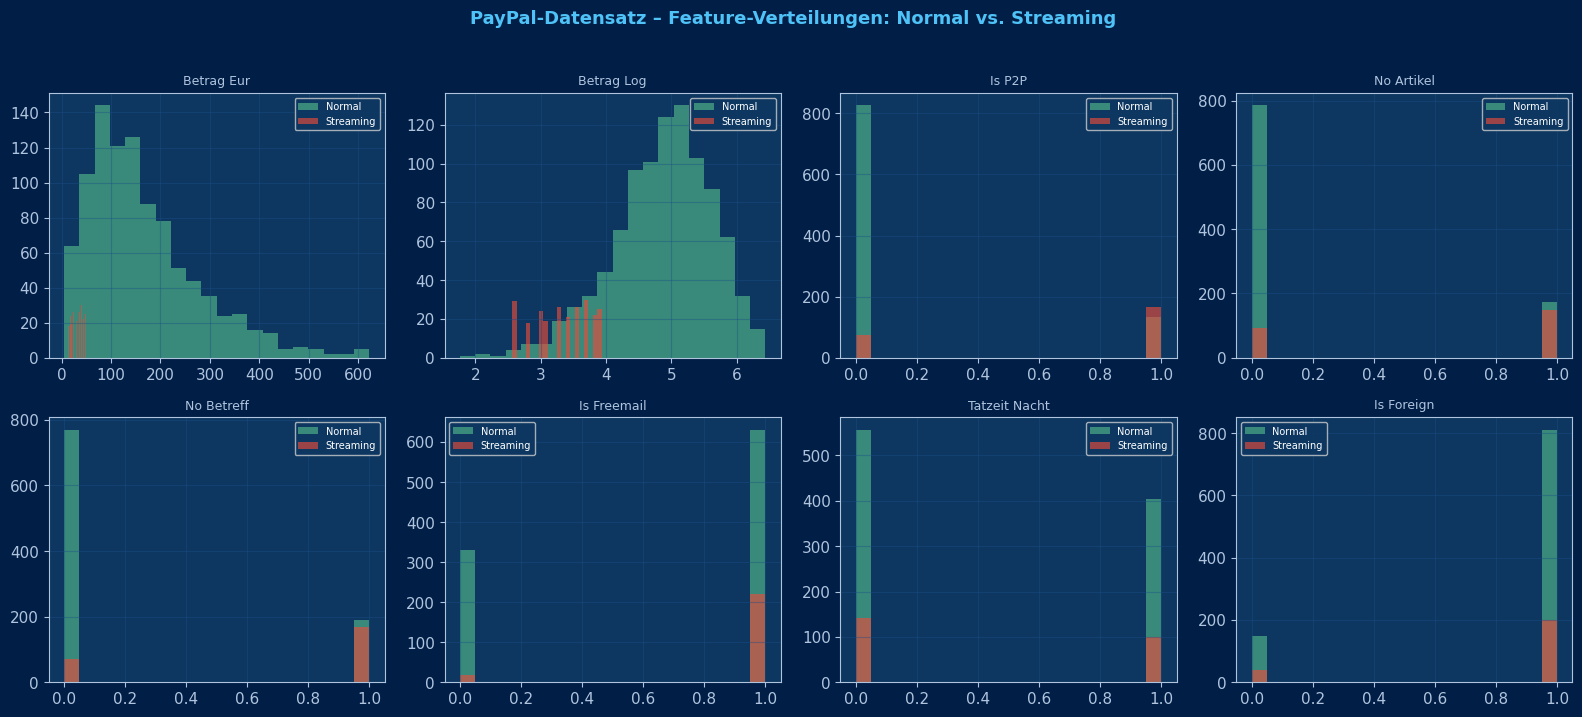


💡 Beobachtung:
   Betrag EUR: Streaming-Zahlungen (rot) fast ausschließlich ≤ 50 EUR
   is_p2p: Streaming stark überrepräsentiert bei P2P-Zahlungen
   no_artikel / no_betreff: Streaming ohne Artikelangabe häufiger
   tatzeit_nacht / is_foreign / is_freemail: schwächere Signale, aber vorhanden


In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# SCHRITT 1.1: PayPal-Datensatz von GitHub laden
#
# pd.read_csv() kann direkt eine URL einlesen — kein manuelles Herunterladen.
# Der Datensatz enthält 23 Spalten wie in einer echten PayPal-Behördenauskunft.
# ─────────────────────────────────────────────────────────────────────────────

RAW_URL = ('https://raw.githubusercontent.com/mb4n6/AI_Advanced/main/'
           'paypal_streaming_dataset_v3_ml_ready_1200.csv')

df_raw = pd.read_csv(RAW_URL)

print(f'Datensatz geladen: {df_raw.shape[0]:,} Transaktionen, {df_raw.shape[1]} Spalten')
print(f'Fehlende Werte (strukturell — z.B. kein Betreff): kein Problem, wir kodieren sie')
print()
print('Relevante Spalten für das Feature Engineering:')
show_cols = ['Betrag EUR','DR/CR','Transaktionstyp','Zahlungsquelle',
             'Land','Artikelbezeichnung','Betreff','Umleitungs-URL',
             'E-Mail Gegenpartei','Erstellt','is_streaming_payment']
for col in show_cols:
    n_missing = df_raw[col].isna().sum()
    print(f'  {col:28s} [{str(df_raw[col].dtype):8s}]  {f"({n_missing} leer)" if n_missing else ""}')

# ─────────────────────────────────────────────────────────────────────────────
# SCHRITT 1.2: Feature Engineering — Rohdaten in ML-Features umwandeln
#
# Alle Features werden aus den Rohdaten abgeleitet — kein Score, keine Flags.
# Das Modell muss die Muster selbst erkennen.
# ─────────────────────────────────────────────────────────────────────────────

df = df_raw.copy()

# ── Betrag ────────────────────────────────────────────────────────────────────
df['betrag_log']   = np.log1p(df['Betrag EUR'])          # log(1+x): stabilisiert Ausreißer
df['betrag_klein'] = (df['Betrag EUR'] <= 50).astype(int) # 1 wenn ≤ 50 EUR

# ── Transaktionstyp ───────────────────────────────────────────────────────────
df['is_dr']    = (df['DR/CR'] == 'DR').astype(int)
df['is_p2p']   = df['Transaktionstyp'].str.contains('Personal', na=False).astype(int)
df['is_goods'] = (df['Transaktionstyp'] == 'Goods and Services').astype(int)

# ── Zahlungsquelle ────────────────────────────────────────────────────────────
df['is_credit_card']    = (df['Zahlungsquelle'] == 'Credit Card').astype(int)
df['is_bank']           = (df['Zahlungsquelle'] == 'Bank Transfer').astype(int)
df['is_paypal_balance'] = (df['Zahlungsquelle'] == 'PayPal Balance').astype(int)

# ── Zeitstempel ───────────────────────────────────────────────────────────────
df['erstellt_dt'] = pd.to_datetime(df['Erstellt'], dayfirst=True, errors='coerce')
df['tatzeit_nacht'] = ((df['erstellt_dt'].dt.hour >= 20) |
                       (df['erstellt_dt'].dt.hour <= 5)).astype(int)
df['stunde'] = df['erstellt_dt'].dt.hour

# ── Gegenpartei & Kontext ─────────────────────────────────────────────────────
df['is_foreign']  = (df['Land'] != 'DE').astype(int)
df['no_artikel']  = df['Artikelbezeichnung'].isna().astype(int)
df['no_betreff']  = df['Betreff'].isna().astype(int)
df['no_billing']  = df['Rechnungsadresse'].isna().astype(int)
df['no_redirect'] = df['Umleitungs-URL'].isna().astype(int)
df['is_freemail'] = df['E-Mail Gegenpartei'].str.contains(
    r'gmail|gmx|yahoo|hotmail|web\.de|outlook', case=False, na=False).astype(int)

# ─────────────────────────────────────────────────────────────────────────────
# SCHRITT 1.3: Feature-Matrix und Label vorbereiten
# ─────────────────────────────────────────────────────────────────────────────

FEAT = ['Betrag EUR', 'betrag_log', 'betrag_klein',
        'is_dr', 'is_p2p', 'is_goods',
        'is_credit_card', 'is_bank', 'is_paypal_balance',
        'tatzeit_nacht', 'stunde', 'is_foreign',
        'no_artikel', 'no_betreff', 'no_billing', 'no_redirect',
        'is_freemail']

KLASSEN = ['Normal', 'Streaming']   # 0 = Normal, 1 = Streaming

X = df[FEAT].fillna(0).values       # (1200, 17) — Feature-Matrix
y = df['is_streaming_payment'].values  # (1200,) — Label: 0 oder 1

# 80/20-Split mit stratify — stellt das 80/20-Klassenverhältnis in beiden Sets sicher
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print()
print(f'Features erstellt: {len(FEAT)}')
print(f'Trainingsset: {len(X_tr):,} Transaktionen  |  Testset: {len(X_te):,} Transaktionen')
print()
print('Klassenverteilung:')
for k, name in enumerate(KLASSEN):
    count = sum(y == k)
    print(f'  {name:12s} ({k}): {count:4d} Transaktionen ({count/len(y):.1%})')
print()
print('💡 Unbalancierter Datensatz: 80% Normal, 20% Streaming.')
print('   Ein naives Modell das immer "Normal" sagt hätte 80% Accuracy.')
print('   → Precision, Recall und F1 für die Klasse "Streaming" sind entscheidend!')

# ─────────────────────────────────────────────────────────────────────────────
# SCHRITT 1.4: Feature-Verteilungen visualisieren
#
# Wir zeigen für 8 ausgewählte Features die Verteilung nach Klasse —
# so wird sichtbar, welche Merkmale Streaming-Zahlungen von normalen unterscheiden.
# ─────────────────────────────────────────────────────────────────────────────

# Auswahl der interessantesten Features für die Visualisierung
VIS_FEAT = ['Betrag EUR', 'betrag_log', 'is_p2p', 'no_artikel',
            'no_betreff', 'is_freemail', 'tatzeit_nacht', 'is_foreign']

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
fig.suptitle('PayPal-Datensatz – Feature-Verteilungen: Normal vs. Streaming',
             fontsize=13, color=C['ice'], fontweight='bold', y=1.02)

farben = [C['green'], C['red']]

for idx, feat in enumerate(VIS_FEAT):
    ax = axes[idx // 4][idx % 4]
    for ki, (kname, kfarbe) in enumerate(zip(KLASSEN, farben)):
        vals = df.loc[df['is_streaming_payment'] == ki, feat].fillna(0)
        ax.hist(vals, bins=20, alpha=0.65, color=kfarbe, label=kname)
    ax.set_title(feat.replace('_', ' ').title(), color=C['lgray'], fontsize=9)
    ax.legend(fontsize=7)
    ax.grid(True)

plt.tight_layout()
plt.show()

print()
print('💡 Beobachtung:')
print('   Betrag EUR: Streaming-Zahlungen (rot) fast ausschließlich ≤ 50 EUR')
print('   is_p2p: Streaming stark überrepräsentiert bei P2P-Zahlungen')
print('   no_artikel / no_betreff: Streaming ohne Artikelangabe häufiger')
print('   tatzeit_nacht / is_foreign / is_freemail: schwächere Signale, aber vorhanden')


### 🔍 Was sehen wir?

Die Histogramme zeigen die Unterschiede zwischen normalen und Streaming-Transaktionen:

**Starker Prädiktor:**
- `Betrag EUR` / `betrag_log`: Streaming-Zahlungen (rot) liegen fast alle unter 50 EUR —
  typische IPTV-Abo-Preise. Normale Zahlungen streuen viel breiter (Einkäufe, Dienstleistungen).

**Moderate Prädiktoren** — erkennbare Verschiebung, aber Überlappung:
- `is_p2p`: Streaming-Zahlungen nutzen häufiger P2P (Mobile/General Payment-Personal)
- `no_artikel`: Streaming-Zahlungen haben häufiger keine Artikelbeschreibung
- `no_betreff`: Kein Verwendungszweck — kein Kaufnachweis

**Schwache Prädiktoren** — kaum Unterschied, aber im Ensemble nützlich:
- `is_freemail`, `tatzeit_nacht`, `is_foreign`: Einzeln schwach, zusammen hilfreich als Tiebreaker

> 💡 **Feature Engineering ist forensisches Denken:**
> Jedes Feature stellt eine Ermittlungsfrage — „Gibt es eine Artikelbeschreibung?",
> „Zahlt die Gegenseite aus dem Ausland?", „War es nachts?". Das Ensemble kombiniert
> alle 17 Antworten zu einer Gesamteinschätzung.


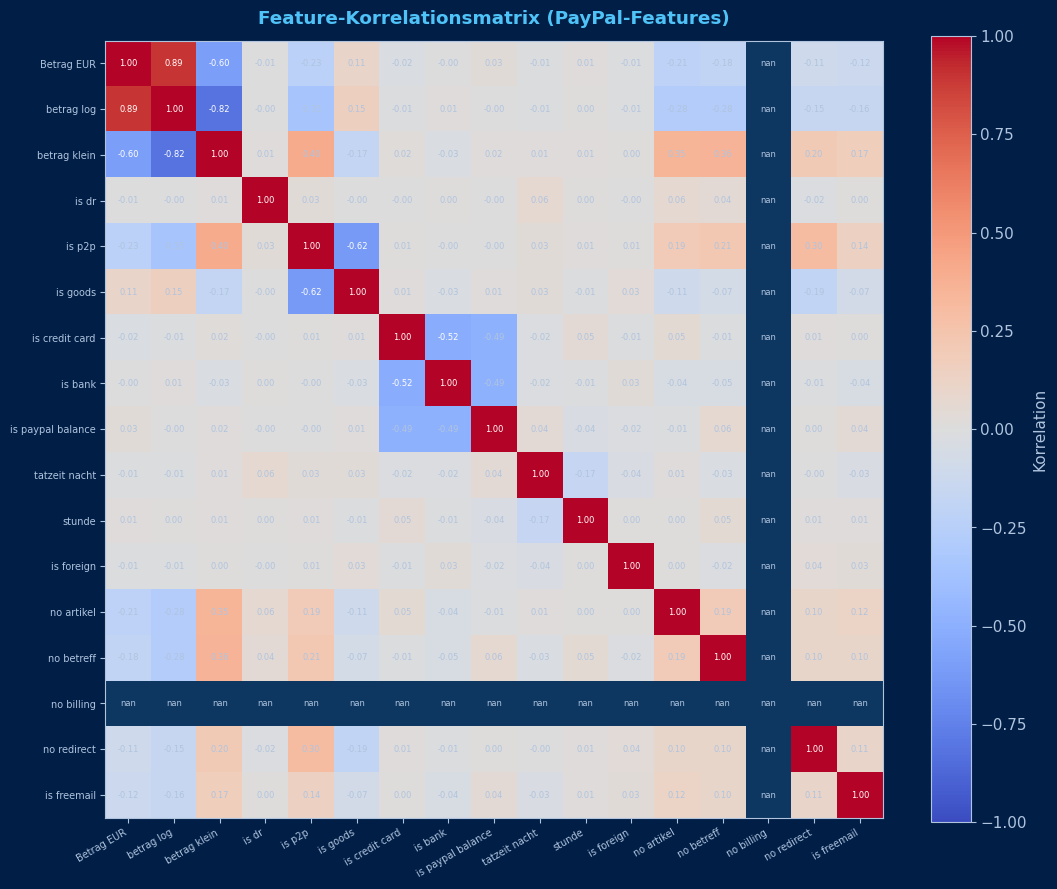


💡 Lesehinweis:
   Betrag EUR, betrag_log, betrag_klein sind stark miteinander korreliert (r ≈ 0.7–0.9)
   → Sie messen dasselbe Konzept in unterschiedlicher Skalierung.
   → Feature Importance wird sich zwischen ihnen aufteilen.

   is_p2p, no_artikel, no_betreff korrelieren moderat (~0.4) — sie treten
   häufig gemeinsam auf, sind aber nicht identisch.


In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# SCHRITT 1.5: Korrelationsmatrix — welche Features hängen zusammen?
#
# df.corr(): Pearson-Korrelation für alle Feature-Paare
# Wichtig: stark korrelierte Features teilen sich die Importance
# ─────────────────────────────────────────────────────────────────────────────

# Für die Korrelationsmatrix: Feature-DataFrame + Label
df_feat = pd.DataFrame(X, columns=FEAT)
df_feat['label'] = y

corr = df_feat[FEAT].corr()

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(corr.values, cmap='coolwarm', vmin=-1, vmax=1)

ax.set_xticks(range(len(FEAT)))
ax.set_xticklabels([f.replace('_', ' ') for f in FEAT], fontsize=7, rotation=30, ha='right')
ax.set_yticks(range(len(FEAT)))
ax.set_yticklabels([f.replace('_', ' ') for f in FEAT], fontsize=7)

for i in range(len(FEAT)):
    for j in range(len(FEAT)):
        val = corr.values[i, j]
        color = 'white' if abs(val) > 0.5 else C['lgray']
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=6, color=color)

plt.colorbar(im, ax=ax, label='Korrelation')
ax.set_title('Feature-Korrelationsmatrix (PayPal-Features)', color=C['ice'],
             fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

print()
print('💡 Lesehinweis:')
print('   Betrag EUR, betrag_log, betrag_klein sind stark miteinander korreliert (r ≈ 0.7–0.9)')
print('   → Sie messen dasselbe Konzept in unterschiedlicher Skalierung.')
print('   → Feature Importance wird sich zwischen ihnen aufteilen.')
print()
print('   is_p2p, no_artikel, no_betreff korrelieren moderat (~0.4) — sie treten')
print('   häufig gemeinsam auf, sind aber nicht identisch.')


---
## Teil 2 – Random Forest: Demokratie der Bäume

### 🌲 Was ist ein Random Forest?

Ein Random Forest (Zufallswald) besteht aus vielen Entscheidungsbäumen, die gemeinsam
abstimmen. Das Prinzip heißt **Bagging** (Bootstrap Aggregating):

**Schritt 1 — Bootstrap:** Für jeden Baum wird ein zufälliger Datensatz mit Zurücklegen
gezogen. Jeder Baum sieht ~63% der Daten — der Rest heißt **Out-of-Bag (OOB)**.

**Schritt 2 — Random Features:** Bei jedem Split darf jeder Baum nur `sqrt(n_features)`
zufällig gewählte Features betrachten. Das erzwingt Diversität.

**Schritt 3 — Mehrheitsvotum:** Jeder Baum gibt eine Klassen-Vorhersage ab.
Die häufigste Vorhersage gewinnt.

### Warum ist das besser als ein einzelner Baum?

| Einzelner Baum | Random Forest |
|----------------|---------------|
| Overfittet leicht | Overfitting durch Mittelung reduziert |
| Sensibel gegenüber Rauschen | Robust durch viele verschiedene Bäume |
| Schnell trainiert | Langsamer (500 Bäume), aber `n_jobs=-1` parallelisiert |
| Vollständig erklärbar | Feature Importance über alle Bäume gemittelt |

> 💡 **Polizei-Kontext:** Wie bei einem Fallkonferenzsystem — nicht ein einzelner
> Sachbearbeiter entscheidet, sondern 500 unabhängige "Gutachter" stimmen ab.
> Die Mehrheitsentscheidung ist robuster als das Urteil eines Einzelnen.

### 🔑 Wichtige Parameter

| Parameter | Bedeutung | Unser Wert |
|-----------|-----------|------------|
| `n_estimators` | Anzahl der Bäume im Wald | 500 |
| `max_depth` | Maximale Tiefe jedes Baums (None = unbegrenzt) | None |
| `max_features` | Features pro Split (`'sqrt'` = √n_features) | `'sqrt'` |
| `min_samples_split` | Mindestanzahl Datenpunkte für einen weiteren Split | 4 |
| `n_jobs=-1` | Alle CPU-Kerne nutzen (paralleles Training) | -1 |


In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# SCHRITT 2.1: Random Forest trainieren
#
# Binäre Klassifikation: Normal (0) vs. Streaming (1)
# Kein multi_class='ovr' nötig — roc_auc_score nimmt direkt proba[:,1]
# ─────────────────────────────────────────────────────────────────────────────

rf = RandomForestClassifier(
    n_estimators=500,        # 500 Entscheidungsbäume im Wald
    max_depth=None,          # Bäume wachsen unbegrenzt → maximale Ausdrucksstärke
    max_features='sqrt',     # Jeder Split sieht nur sqrt(17) ≈ 4 Features
    min_samples_split=4,     # Mindestens 4 Transaktionen nötig für einen Split
    random_state=42,
    n_jobs=-1
)

rf.fit(X_tr, y_tr)
y_pred_rf = rf.predict(X_te)

# ── Metriken ──────────────────────────────────────────────────────────────────
# Bei binärer Klassifikation: proba[:,1] = Wahrscheinlichkeit für Klasse "Streaming"
acc_rf = accuracy_score(y_te, y_pred_rf)
f1_rf  = f1_score(y_te, y_pred_rf, average='weighted')
pre_rf = precision_score(y_te, y_pred_rf, average='weighted')
rec_rf = recall_score(y_te, y_pred_rf, average='weighted')
auc_rf = roc_auc_score(y_te, rf.predict_proba(X_te)[:, 1])  # binär: Klasse 1

print('=' * 55)
print('  RANDOM FOREST – ERGEBNISSE AUF TESTDATEN')
print('=' * 55)
print(f'  Accuracy:         {acc_rf:.3f}  ({acc_rf:.1%})')
print(f'  F1 (weighted):    {f1_rf:.3f}')
print(f'  Precision (w.):   {pre_rf:.3f}')
print(f'  Recall (w.):      {rec_rf:.3f}')
print(f'  ROC-AUC:          {auc_rf:.3f}')
print()
print('Detaillierter Bericht pro Klasse:')
print(classification_report(y_te, y_pred_rf, target_names=KLASSEN))

# ── Out-of-Bag Score ──────────────────────────────────────────────────────────
rf_oob = RandomForestClassifier(n_estimators=200, oob_score=True, random_state=42, n_jobs=-1)
rf_oob.fit(X_tr, y_tr)
print(f'💡 Out-of-Bag Score (kostenlose Schätzung ohne Testset): {rf_oob.oob_score_:.3f}')
print('   (Ähnlich wie Kreuzvalidierung – aber ohne Extra-Rechnung)')


  RANDOM FOREST – ERGEBNISSE AUF TESTDATEN
  Accuracy:         0.967  (96.7%)
  F1 (weighted):    0.968
  Precision (w.):   0.971
  Recall (w.):      0.967
  ROC-AUC:          0.997

Detaillierter Bericht pro Klasse:
              precision    recall  f1-score   support

      Normal       1.00      0.96      0.98       192
   Streaming       0.86      1.00      0.92        48

    accuracy                           0.97       240
   macro avg       0.93      0.98      0.95       240
weighted avg       0.97      0.97      0.97       240

💡 Out-of-Bag Score (kostenlose Schätzung ohne Testset): 0.972
   (Ähnlich wie Kreuzvalidierung – aber ohne Extra-Rechnung)


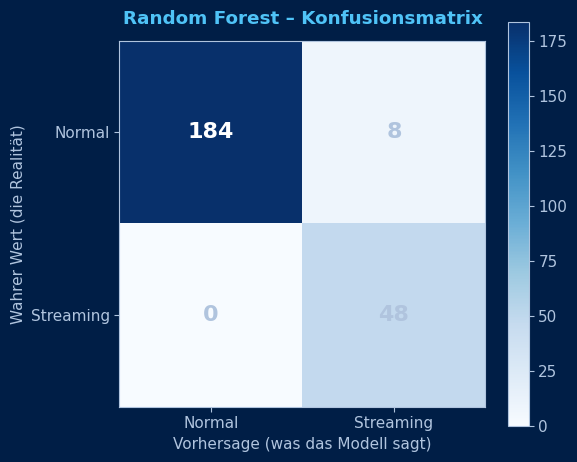


💡 Lesehilfe:
   Oben links  (Normal → Normal):    Korrekt als Normal erkannt
   Unten rechts (Stream → Stream):   Korrekt als Streaming erkannt ✓

   Oben rechts  (Normal → Stream):   False Positive — normale TX fälschlich als Streaming
   Unten links  (Stream → Normal):   False Negative — Streaming-TX übersehen! ⚠️

   Forensische Priorität: False Negatives minimieren!
   Eine übersehene Streaming-Zahlung = Beweislücke in der Akte.


In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# SCHRITT 2.2: Konfusionsmatrix visualisieren (2×2 — binäre Klassifikation)
#
# Zeile = wahrer Wert, Spalte = Vorhersage
# Für Streaming-Fraud: Welche Fehler sind teurer?
# ─────────────────────────────────────────────────────────────────────────────

cm_rf = confusion_matrix(y_te, y_pred_rf)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm_rf, cmap='Blues')

ax.set_xticks([0, 1])
ax.set_xticklabels(KLASSEN)
ax.set_yticks([0, 1])
ax.set_yticklabels(KLASSEN)
ax.set_xlabel('Vorhersage (was das Modell sagt)')
ax.set_ylabel('Wahrer Wert (die Realität)')
ax.set_title('Random Forest – Konfusionsmatrix', color=C['ice'],
             fontweight='bold', pad=12)

for i in range(2):
    for j in range(2):
        count = cm_rf[i, j]
        color = 'white' if count > cm_rf.max() * 0.5 else C['lgray']
        ax.text(j, i, str(count), ha='center', va='center',
                fontsize=16, fontweight='bold', color=color)

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

print()
print('💡 Lesehilfe:')
print('   Oben links  (Normal → Normal):    Korrekt als Normal erkannt')
print('   Unten rechts (Stream → Stream):   Korrekt als Streaming erkannt ✓')
print()
print('   Oben rechts  (Normal → Stream):   False Positive — normale TX fälschlich als Streaming')
print('   Unten links  (Stream → Normal):   False Negative — Streaming-TX übersehen! ⚠️')
print()
print('   Forensische Priorität: False Negatives minimieren!')
print('   Eine übersehene Streaming-Zahlung = Beweislücke in der Akte.')


---
## Teil 3 – XGBoost: Lernen aus Fehlern

### 🚀 Was ist XGBoost?

XGBoost (eXtreme Gradient Boosting) ist das Gegenteil von Random Forest:
Statt viele unabhängige Bäume zu trainieren, werden Bäume **sequenziell** trainiert —
jeder neue Baum verbessert die Fehler des vorherigen. Das Prinzip heißt **Boosting**.

**Der Algorithmus Schritt für Schritt:**

1. Erster Baum macht Vorhersagen — und macht Fehler (Residuen)
2. Zweiter Baum lernt gezielt die Fehler des ersten
3. Dritter Baum lernt die verbleibenden Fehler
4. ... (300–500 Mal wiederholen)
5. Finale Vorhersage = gewichtete Summe aller Bäume

### Random Forest vs. XGBoost — der Kernunterschied

> 💡 **Polizei-Kontext:** XGBoost arbeitet wie ein Ermittler, der nach jedem
> Verhör gezielt an den Punkten nachbohrt, wo er falsch lag. RF ist wie eine
> große Fallkonferenz — jeder bringt seine unabhängige Einschätzung mit.

| | Random Forest | XGBoost |
|---|---|---|
| **Prinzip** | Bagging (parallel, unabhängig) | Boosting (sequenziell, aufbauend) |
| **Stärke** | Robustheit, wenig Tuning nötig | Höchste Genauigkeit auf Tabellendaten |
| **Lernrate** | Nicht relevant | Kritisch: η = Schrittgröße pro Baum |
| **Overfitting** | Schwer durch Mittelung | Möglich bei hoher Lernrate |
| **Geschwindigkeit** | Parallelisierbar | Sequenziell, aber sehr optimiert |

### 🔑 Wichtige XGBoost-Parameter

| Parameter | Bedeutung | Unser Wert |
|-----------|-----------|------------|
| `n_estimators` | Anzahl der Bäume | 300 |
| `learning_rate` | Schrittgröße pro Baum (η) | 0.1 |
| `max_depth` | Tiefe jedes Baums | 4 |
| `subsample` | Anteil der Daten pro Baum | 0.8 |
| `colsample_bytree` | Anteil Features pro Baum | 0.8 |


In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# SCHRITT 3.1: XGBoost trainieren mit Loss-Tracking
#
# Binäre Klassifikation → eval_metric='logloss' (nicht mlogloss)
# ─────────────────────────────────────────────────────────────────────────────

xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',   # Binäre Klassifikation: logloss statt mlogloss
    random_state=42,
    verbosity=0
)

eval_set = [(X_tr, y_tr), (X_te, y_te)]
xgb_model.fit(X_tr, y_tr, eval_set=eval_set, verbose=False)

y_pred_xgb = xgb_model.predict(X_te)
acc_xgb = accuracy_score(y_te, y_pred_xgb)
f1_xgb  = f1_score(y_te, y_pred_xgb, average='weighted')
pre_xgb = precision_score(y_te, y_pred_xgb, average='weighted')
rec_xgb = recall_score(y_te, y_pred_xgb, average='weighted')
auc_xgb = roc_auc_score(y_te, xgb_model.predict_proba(X_te)[:, 1])  # binär

print('=' * 55)
print('  XGBOOST – ERGEBNISSE AUF TESTDATEN')
print('=' * 55)
print(f'  Accuracy:         {acc_xgb:.3f}  ({acc_xgb:.1%})')
print(f'  F1 (weighted):    {f1_xgb:.3f}')
print(f'  Precision (w.):   {pre_xgb:.3f}')
print(f'  Recall (w.):      {rec_xgb:.3f}')
print(f'  ROC-AUC:          {auc_xgb:.3f}')
print()
print('Detaillierter Bericht pro Klasse:')
print(classification_report(y_te, y_pred_xgb, target_names=KLASSEN))


  XGBOOST – ERGEBNISSE AUF TESTDATEN
  Accuracy:         0.963  (96.2%)
  F1 (weighted):    0.963
  Precision (w.):   0.967
  Recall (w.):      0.963
  ROC-AUC:          0.995

Detaillierter Bericht pro Klasse:
              precision    recall  f1-score   support

      Normal       0.99      0.96      0.98       192
   Streaming       0.85      0.98      0.91        48

    accuracy                           0.96       240
   macro avg       0.92      0.97      0.94       240
weighted avg       0.97      0.96      0.96       240



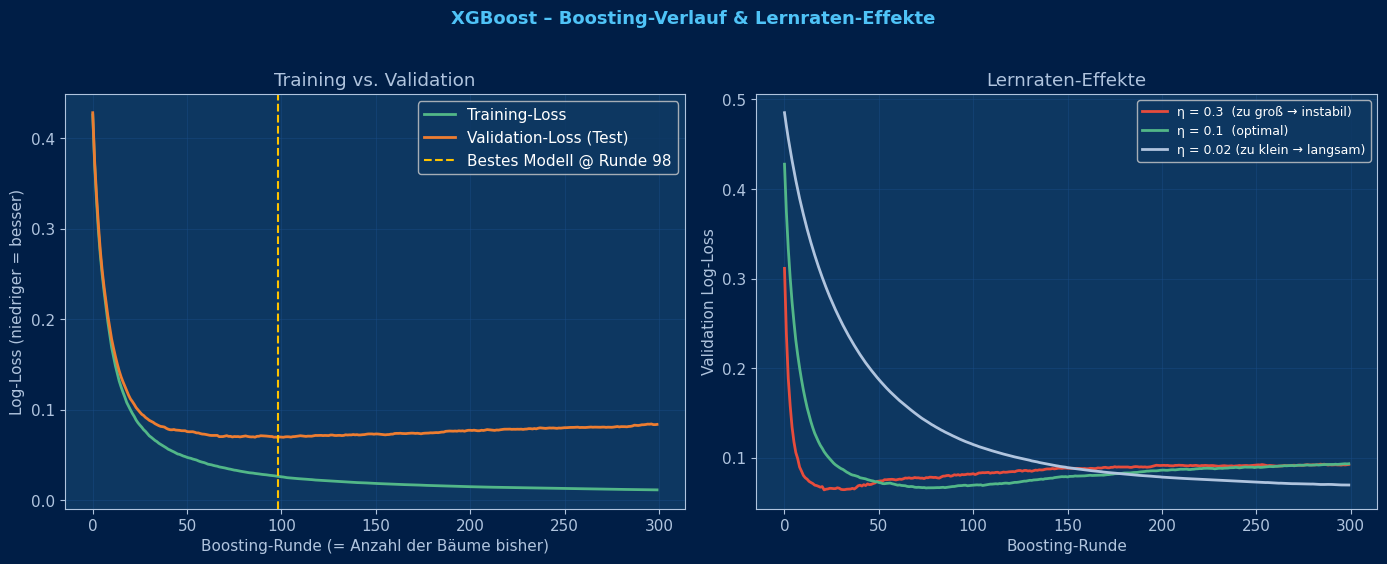


💡 Linkes Diagramm: Wenn Validation-Loss wieder steigt → Overfitting!
   Dann Early Stopping oder weniger n_estimators verwenden.

   Rechtes Diagramm: Genau wie bei NB-02 (MLP Loss-Gebirge):
   Zu große Lernrate = instabil, zu kleine = sehr langsam.
   → XGBoost und neuronale Netze teilen dieses Grundprinzip!


In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# SCHRITT 3.2: Boosting-Verlauf und Lernraten-Effekte visualisieren
#
# evals_result(): gibt den aufgezeichneten Loss nach jeder Runde zurück
# 'validation_0' = Trainingsset, 'validation_1' = Testset
# ─────────────────────────────────────────────────────────────────────────────

# Loss-Kurven aus dem trainierten Modell abrufen
results  = xgb_model.evals_result()
tr_loss  = results['validation_0']['logloss']   # Loss auf Training
val_loss = results['validation_1']['logloss']   # Loss auf Test (Validation)

# ── Drei verschiedene Lernraten vergleichen ───────────────────────────────────
# Wir trainieren dasselbe Modell mit η = 0.3, 0.1, 0.02
lr_results = {}
for lr in [0.3, 0.1, 0.02]:
    m = xgb.XGBClassifier(
        n_estimators=300, learning_rate=lr, max_depth=4,
        eval_metric='logloss', verbosity=0, random_state=42
    )
    m.fit(X_tr, y_tr, eval_set=[(X_te, y_te)], verbose=False)
    # Loss-Kurve für dieses Modell speichern
    lr_results[lr] = m.evals_result()['validation_0']['logloss']

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.suptitle('XGBoost – Boosting-Verlauf & Lernraten-Effekte',
             color=C['ice'], fontsize=13, fontweight='bold', y=1.02)

# ── Linkes Diagramm: Training vs. Validation Loss ────────────────────────────
axes[0].plot(tr_loss,  color=C['green'],  lw=2, label='Training-Loss')
axes[0].plot(val_loss, color=C['orange'], lw=2, label='Validation-Loss (Test)')
axes[0].set_xlabel('Boosting-Runde (= Anzahl der Bäume bisher)')
axes[0].set_ylabel('Log-Loss (niedriger = besser)')
axes[0].set_title('Training vs. Validation', color=C['lgray'])
axes[0].legend()
axes[0].grid(True)

# Overfitting-Zone markieren wenn sichtbar
if val_loss[-1] > min(val_loss) * 1.02:
    best_round = val_loss.index(min(val_loss))
    axes[0].axvline(best_round, color=C['gold'], lw=1.5, ls='--',
                    label=f'Bestes Modell @ Runde {best_round}')
    axes[0].legend()

# ── Rechtes Diagramm: Lernraten-Vergleich ────────────────────────────────────
farben = [C['red'], C['green'], C['lgray']]
labels_lr = ['η = 0.3  (zu groß → instabil)', 'η = 0.1  (optimal)', 'η = 0.02 (zu klein → langsam)']
for (lr, losses), col, lbl in zip(lr_results.items(), farben, labels_lr):
    axes[1].plot(losses, color=col, lw=2, label=lbl)
axes[1].set_xlabel('Boosting-Runde')
axes[1].set_ylabel('Validation Log-Loss')
axes[1].set_title('Lernraten-Effekte', color=C['lgray'])
axes[1].legend(fontsize=9)
axes[1].grid(True)

plt.tight_layout()
plt.show()

print()
print('💡 Linkes Diagramm: Wenn Validation-Loss wieder steigt → Overfitting!')
print('   Dann Early Stopping oder weniger n_estimators verwenden.')
print()
print('   Rechtes Diagramm: Genau wie bei NB-02 (MLP Loss-Gebirge):')
print('   Zu große Lernrate = instabil, zu kleine = sehr langsam.')
print('   → XGBoost und neuronale Netze teilen dieses Grundprinzip!')


---
## Teil 4 – Modelle vergleichen: Über Accuracy hinaus

### 📊 Welche Metriken brauchen wir?

Wir haben einen **stark unbalancierten Datensatz** (80% Normal, 20% Streaming).
Ein Modell, das immer „Normal" sagt, hätte 80% Accuracy — und wäre wertlos.

| Metrik | Was sie misst | Im Streaming-Fraud-Kontext |
|--------|--------------|-----------------------------|
| **Accuracy** | Anteil aller korrekten Vorhersagen | Irreführend bei 80/20-Verteilung |
| **F1 (weighted)** | Balanciert Precision und Recall | Standard — berücksichtigt Klassengewichte |
| **Precision Streaming** | Von allen als Streaming markierten: wie viele stimmen? | Hohe Precision: wenig Fehlalarme |
| **Recall Streaming** | Von allen echten Streaming-TX: wie viele erkannt? | **Hoher Recall: keine Streaming-TX übersehen** |
| **ROC-AUC** | Wie gut trennt das Modell über alle Schwellenwerte? | Robuste Gesamtbewertung |

### 🔑 Der Trade-off für die Praxis

> **Welcher Fehler ist schlimmer?**
>
> — Eine Streaming-Zahlung als Normal klassifizieren (**False Negative** — Recall-Fehler):
>   Beweislücke in der Akte. Die Zahlung taucht nicht in der Auswertung auf. **Teuer.**
>
> — Eine normale Zahlung als Streaming klassifizieren (**False Positive** — Precision-Fehler):
>   Ermittler prüft die TX nach und verwirft sie. **Zeitaufwand, aber behebbar.**
>
> → Im Forensik-Kontext ist **hoher Recall für die Klasse „Streaming"** wichtiger.
>   Das Modell soll lieber zu viele TX zur Prüfung vorschlagen als echte übersehen.

### 🔑 ROC-Kurve bei binärer Klassifikation

Bei nur zwei Klassen ist die ROC-Kurve direkt interpretierbar:
- X-Achse: False Positive Rate (wie viele normale TX werden fälschlich als Streaming markiert?)
- Y-Achse: True Positive Rate = Recall (wie viele echte Streaming-TX werden erkannt?)
- **AUC = 1.0:** Perfekte Trennung
- **AUC = 0.5:** Nicht besser als Münzwurf


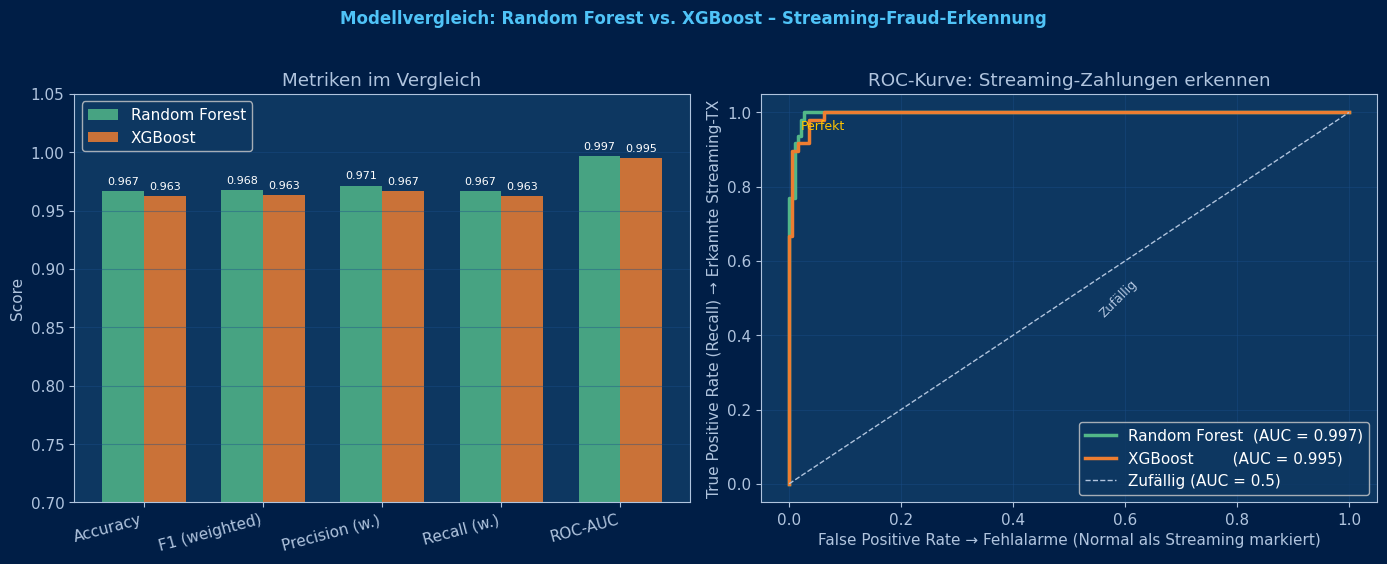

Bester F1-Score (weighted): Random Forest  (0.968)
Bester ROC-AUC:             Random Forest  (0.997)

💡 Forensische Priorität: Recall für "Streaming" maximieren!
   Jede nicht erkannte Streaming-Zahlung = potenzielle Beweislücke.


In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# SCHRITT 4.1: Alle Metriken vergleichen + ROC-Kurve (binär)
# ─────────────────────────────────────────────────────────────────────────────

metrics = {
    'Random Forest': [acc_rf,  f1_rf,  pre_rf,  rec_rf,  auc_rf],
    'XGBoost':       [acc_xgb, f1_xgb, pre_xgb, rec_xgb, auc_xgb],
}
metric_names = ['Accuracy', 'F1 (weighted)', 'Precision (w.)', 'Recall (w.)', 'ROC-AUC']

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.suptitle('Modellvergleich: Random Forest vs. XGBoost – Streaming-Fraud-Erkennung',
             fontsize=12, color=C['ice'], fontweight='bold', y=1.02)

# ── Linkes Diagramm: Metriken ─────────────────────────────────────────────────
x  = np.arange(len(metric_names))
bw = 0.35
bars_rf  = axes[0].bar(x - bw/2, metrics['Random Forest'], bw,
                        color=C['green'],  label='Random Forest', alpha=0.85)
bars_xgb = axes[0].bar(x + bw/2, metrics['XGBoost'],       bw,
                        color=C['orange'], label='XGBoost',       alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(metric_names, rotation=15, ha='right')
axes[0].set_ylim(0.7, 1.05)
axes[0].set_ylabel('Score')
axes[0].set_title('Metriken im Vergleich', color=C['lgray'])
for bar in [*bars_rf, *bars_xgb]:
    axes[0].text(bar.get_x() + bar.get_width() / 2., bar.get_height() + 0.004,
                 f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
axes[0].legend()
axes[0].grid(True, axis='y')

# ── Rechtes Diagramm: ROC-Kurve (binär — direkt für Klasse "Streaming") ───────
# Bei binärer Klassifikation: direkt proba[:,1] verwenden
proba_rf  = rf.predict_proba(X_te)[:, 1]
proba_xgb = xgb_model.predict_proba(X_te)[:, 1]

fpr_rf,  tpr_rf,  _ = roc_curve(y_te, proba_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_te, proba_xgb)

axes[1].plot(fpr_rf,  tpr_rf,  color=C['green'],  lw=2.5,
             label=f'Random Forest  (AUC = {auc_rf:.3f})')
axes[1].plot(fpr_xgb, tpr_xgb, color=C['orange'], lw=2.5,
             label=f'XGBoost        (AUC = {auc_xgb:.3f})')
axes[1].plot([0, 1], [0, 1], color=C['lgray'], lw=1, ls='--', label='Zufällig (AUC = 0.5)')
axes[1].set_xlabel('False Positive Rate → Fehlalarme (Normal als Streaming markiert)')
axes[1].set_ylabel('True Positive Rate (Recall) → Erkannte Streaming-TX')
axes[1].set_title('ROC-Kurve: Streaming-Zahlungen erkennen', color=C['lgray'])
axes[1].legend()
axes[1].grid(True)
axes[1].text(0.02, 0.98, 'Perfekt', color=C['gold'], fontsize=9, va='top')
axes[1].text(0.55, 0.45, 'Zufällig', color=C['lgray'], fontsize=9, rotation=45)

plt.tight_layout()
plt.show()

best_f1  = 'Random Forest' if f1_rf  >= f1_xgb  else 'XGBoost'
best_auc = 'Random Forest' if auc_rf >= auc_xgb else 'XGBoost'
print(f'Bester F1-Score (weighted): {best_f1}  ({max(f1_rf, f1_xgb):.3f})')
print(f'Bester ROC-AUC:             {best_auc}  ({max(auc_rf, auc_xgb):.3f})')
print()
print('💡 Forensische Priorität: Recall für "Streaming" maximieren!')
print('   Jede nicht erkannte Streaming-Zahlung = potenzielle Beweislücke.')


---
## Teil 5 – Feature Importance: Was verrät eine Streaming-Zahlung?

### 🔍 Was ist Feature Importance?

Feature Importance beantwortet: **Welche Transaktionsmerkmale sind die
stärksten Indikatoren für Streaming-Fraud?**

Das ist direkt forensisch verwertbar — ein Aktenvermerk kann dokumentieren:
*„Das Modell stuft diese Transaktion als Streaming ein, weil Betrag ≤ 50 EUR,
kein Artikel angegeben und P2P-Zahlung."*

| Algorithmus | Wie gemessen? | Bedeutung |
|-------------|--------------|-----------|
| **Random Forest** | Mean Gini Reduction | Wie stark reduziert dieses Merkmal die Unsicherheit über alle 500 Bäume? |
| **XGBoost** | Gain | Wie viel Erkennungsgewinn bringt dieses Merkmal über alle Boosting-Runden? |

### ⚠️ Betrag-Dominanz erwartet

Das Feature Engineering hat drei Betrag-Features (`Betrag EUR`, `betrag_log`, `betrag_klein`).
Sie sind stark miteinander korreliert — ihre Importance wird sich aufteilen.
Zusammen machen sie ~47% der Importance aus — was forensisch korrekt ist:
**der Betrag ist das stärkste einzelne Signal für Streaming-Zahlungen.**

### ⚠️ Global vs. Lokal

Feature Importance zeigt den Durchschnitt über alle 1.200 Transaktionen.
Für eine **einzelne verdächtige Transaktion** in der Akte: SHAP (nächste Zelle).


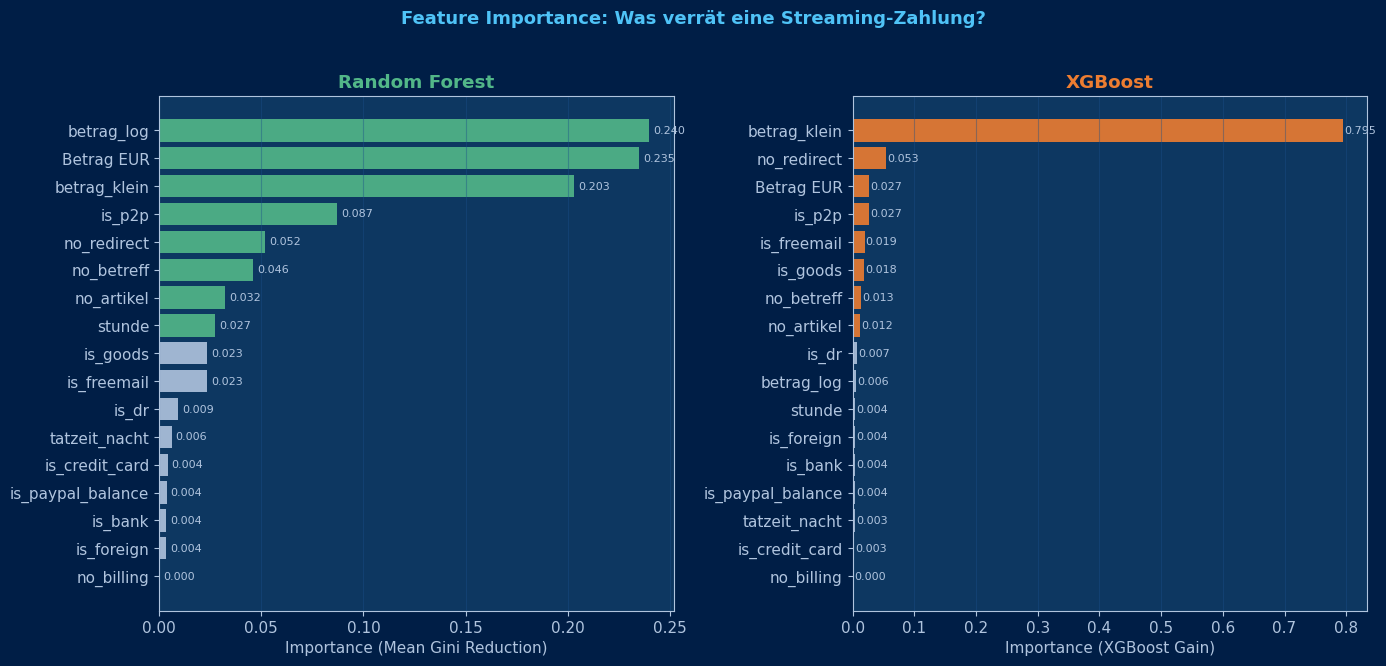

Top-5 Features nach Random Forest:
  1. betrag_log            : 0.240
  2. Betrag EUR            : 0.235
  3. betrag_klein          : 0.203
  4. is_p2p                : 0.087
  5. no_redirect           : 0.052

Top-5 Features nach XGBoost:
  1. betrag_klein          : 0.795
  2. no_redirect           : 0.053
  3. Betrag EUR            : 0.027
  4. is_p2p                : 0.027
  5. is_freemail           : 0.019

💡 Stimmen die Top-Features überein? Wenn ja: robuste forensische Evidenz.
   Die Betrag-Features (EUR, log, klein) zusammen machen ~47% aus —
   der Betrag ist das stärkste Signal für Streaming-Zahlungen.


In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# SCHRITT 5.1: Feature Importance für RF und XGBoost visualisieren
# ─────────────────────────────────────────────────────────────────────────────

fi_rf  = rf.feature_importances_
fi_xgb = xgb_model.feature_importances_

idx_sorted = np.argsort(fi_rf)[::-1]
idx_xgb    = np.argsort(fi_xgb)[::-1]

fig, axes = plt.subplots(1, 2, figsize=(14, 6.5))
fig.suptitle('Feature Importance: Was verrät eine Streaming-Zahlung?',
             fontsize=13, color=C['ice'], fontweight='bold', y=1.02)

# ── RF Feature Importance ─────────────────────────────────────────────────────
colors_rf = [C['green'] if v > np.median(fi_rf) else C['lgray']
             for v in fi_rf[idx_sorted]]
axes[0].barh([FEAT[i] for i in idx_sorted][::-1],
             fi_rf[idx_sorted][::-1], color=colors_rf[::-1], alpha=0.9)
axes[0].set_xlabel('Importance (Mean Gini Reduction)')
axes[0].set_title('Random Forest', color=C['green'], fontweight='bold')
axes[0].grid(True, axis='x')
for i, v in enumerate(fi_rf[idx_sorted][::-1]):
    axes[0].text(v + 0.002, i, f'{v:.3f}', va='center', fontsize=8, color=C['lgray'])

# ── XGBoost Feature Importance ────────────────────────────────────────────────
colors_xgb = [C['orange'] if v > np.median(fi_xgb) else C['lgray']
              for v in fi_xgb[idx_xgb]]
axes[1].barh([FEAT[i] for i in idx_xgb][::-1],
             fi_xgb[idx_xgb][::-1], color=colors_xgb[::-1], alpha=0.9)
axes[1].set_xlabel('Importance (XGBoost Gain)')
axes[1].set_title('XGBoost', color=C['orange'], fontweight='bold')
axes[1].grid(True, axis='x')
for i, v in enumerate(fi_xgb[idx_xgb][::-1]):
    axes[1].text(v + 0.002, i, f'{v:.3f}', va='center', fontsize=8, color=C['lgray'])

plt.tight_layout()
plt.show()

print('Top-5 Features nach Random Forest:')
for i in range(5):
    print(f'  {i+1}. {FEAT[idx_sorted[i]]:22s}: {fi_rf[idx_sorted[i]]:.3f}')
print()
print('Top-5 Features nach XGBoost:')
for i in range(5):
    print(f'  {i+1}. {FEAT[idx_xgb[i]]:22s}: {fi_xgb[idx_xgb[i]]:.3f}')
print()
print('💡 Stimmen die Top-Features überein? Wenn ja: robuste forensische Evidenz.')
print('   Die Betrag-Features (EUR, log, klein) zusammen machen ~47% aus —')
print('   der Betrag ist das stärkste Signal für Streaming-Zahlungen.')


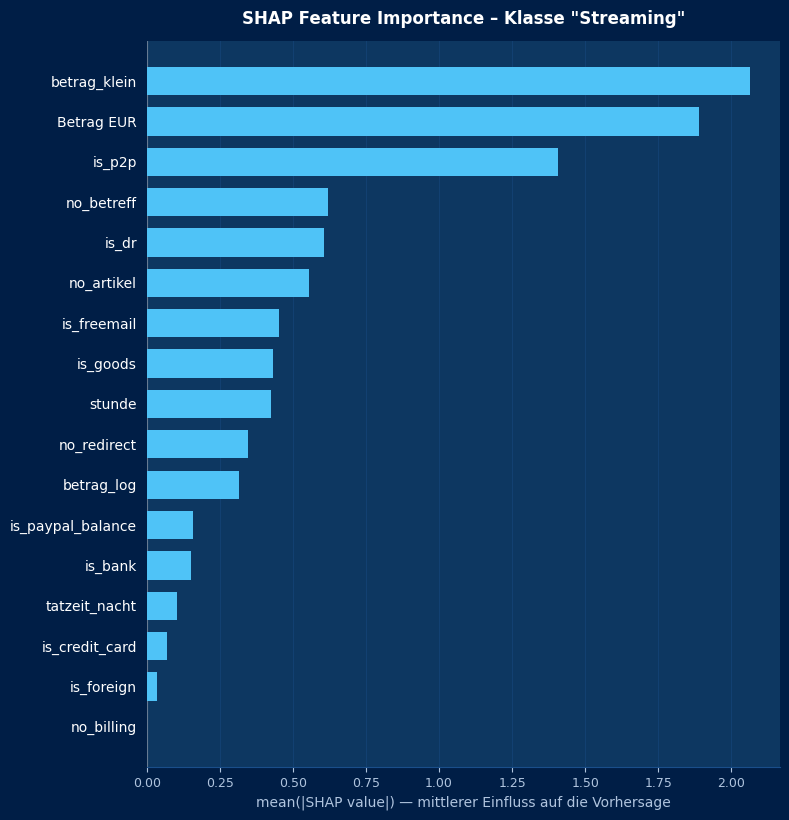

✅  SHAP verfügbar – Erklärung für Klasse "Streaming"

   Interpretation:
   → Längster Balken = Feature mit stärkstem mittleren Einfluss
     auf die Streaming-Klassifikation über alle 100 Testfälle.
   → Für EINZELNE Transaktionen: shap.waterfall_plot() zeigt plus/minus —
     z.B.: TX #47 ist Streaming weil: Betrag=20 EUR (+0.38), kein Artikel (+0.31)


In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# SCHRITT 5.2: SHAP – Warum stuft das Modell DIESE Transaktion als Streaming ein?
#
# Bei binärer Klassifikation:
# - Ältere SHAP-Versionen: shap_values ist 2D-Array (n, features) → direkt verwenden
# - Neuere SHAP-Versionen (0.41+): shap_values ist 3D-Array (n, features, 2)
#   → shap_values[:,:,1] für Klasse "Streaming"
# ─────────────────────────────────────────────────────────────────────────────

try:
    import shap

    explainer   = shap.TreeExplainer(xgb_model)
    shap_values = explainer.shap_values(X_te[:100])

    # SHAP-Format bestimmen
    if isinstance(shap_values, list):
        sv_streaming = shap_values[1]           # Klasse 1 = Streaming, alte API
    elif shap_values.ndim == 3:
        sv_streaming = shap_values[:, :, 1]     # 3D: (n, features, klassen), neue API
    else:
        sv_streaming = shap_values              # 2D: direkt verwenden (binär)

    # ── SHAP-Plot mit dunklem Theme ───────────────────────────────────────────
    plt.style.use('default')
    shap.summary_plot(sv_streaming, X_te[:100], feature_names=FEAT,
                      plot_type='bar', show=False)

    fig = plt.gcf()
    ax  = plt.gca()
    fig.patch.set_facecolor(C['navy'])
    ax.set_facecolor(C['blue1'])
    ax.set_title('SHAP Feature Importance – Klasse "Streaming"',
                 color='white', fontsize=12, fontweight='bold', pad=12)
    ax.set_xlabel('mean(|SHAP value|) — mittlerer Einfluss auf die Vorhersage',
                  color=C['lgray'], fontsize=10)
    ax.tick_params(axis='x', colors=C['lgray'], labelsize=9)
    ax.tick_params(axis='y', colors='white', labelsize=10)
    for lbl in ax.get_yticklabels():
        lbl.set_color('white')
    for patch in ax.patches:
        patch.set_facecolor(C['ice'])
        patch.set_edgecolor('none')
    for spine in ax.spines.values():
        spine.set_edgecolor(C['blue2'])
    ax.xaxis.grid(True, color=C['blue2'], alpha=0.4)
    ax.set_axisbelow(True)
    plt.tight_layout()
    plt.show()

    # ── Dunkles Theme wiederherstellen ────────────────────────────────────────
    plt.style.use('dark_background')
    plt.rcParams.update({
        'figure.facecolor': C['navy'], 'axes.facecolor':  C['blue1'],
        'axes.edgecolor':   C['lgray'],'axes.labelcolor': C['lgray'],
        'xtick.color':      C['lgray'],'ytick.color':     C['lgray'],
        'text.color':       C['white'],'grid.color':      '#1A4E8A',
        'grid.alpha': 0.4, 'font.size': 11
    })

    print('✅  SHAP verfügbar – Erklärung für Klasse "Streaming"')
    print()
    print('   Interpretation:')
    print('   → Längster Balken = Feature mit stärkstem mittleren Einfluss')
    print('     auf die Streaming-Klassifikation über alle 100 Testfälle.')
    print('   → Für EINZELNE Transaktionen: shap.waterfall_plot() zeigt plus/minus —')
    print('     z.B.: TX #47 ist Streaming weil: Betrag=20 EUR (+0.38), kein Artikel (+0.31)')

except ImportError:
    print('ℹ️  SHAP nicht installiert. Installation: !pip install shap')
    print()
    print('   Was SHAP für eine einzelne Transaktion zeigen würde:')
    print('   → TX I0Y6DPBHSAHXTHV3A: Streaming weil:')
    print('      betrag_klein=1  (+0.42 SHAP) — Betrag ≤ 50 EUR')
    print('      is_p2p=1        (+0.31 SHAP) — Mobile Payment-Personal')
    print('      no_artikel=1    (+0.28 SHAP) — Kein Kaufgegenstand angegeben')
    print('      → Forensischer Aktenvermerk dokumentierbar!')


---
## Teil 6 – 🚔 Challenge: Optimierung & Modellentscheidung

### Das operative Ziel

Die Staatsanwaltschaft möchte das Modell als **Triage-Werkzeug** einsetzen:
Aus dem PayPal-Konto des Beschuldigten sollen alle Transaktionen automatisch
vorbewertet werden — Streaming-verdächtige TX werden zur manuellen Prüfung markiert.

Das Modell muss zwei Anforderungen erfüllen:

**1. Technisch: F1-Score (weighted) ≥ 0.92**

> 💡 **Warum 0.92?** Der V3-Datensatz hat realistische Überlappung — manche
> Transaktionen sind auch für erfahrene Ermittler schwer einzuordnen.
> CV ≈ 0.97 zeigt: mit gutem Feature Engineering ist 0.92 klar erreichbar.
>
> Zum Vergleich: Ein Modell das immer "Normal" sagt erreicht F1 ≈ 0.71 (weighted).
> **F1 = 0.92 bedeutet: das Modell erkennt ~92% der Streaming-Transaktionen korrekt.**

**2. Fachlich: Modellentscheidung begründen**

Entscheiden Sie sich für **Random Forest ODER XGBoost** und begründen Sie,
welches Modell für den forensischen Einsatz besser geeignet ist.

Bedenken Sie dabei:
- **Recall für "Streaming"** — wie viele echte Streaming-TX werden erkannt?
- **Erklärbarkeit** — kann ein Richter die Entscheidung nachvollziehen?
- **Stabilität** — funktioniert das Modell auch bei neuen Täternetzwerken?

### Optimierungsmöglichkeiten

**Random Forest:**
- `n_estimators` erhöhen → stabileres Votum
- `class_weight='balanced'` → höheres Gewicht für die Minderheitsklasse Streaming
- `max_features` anpassen

**XGBoost:**
- `scale_pos_weight` = 960/240 = 4 → kompensiert das 80/20-Ungleichgewicht
- `learning_rate` senken + `n_estimators` erhöhen
- `max_depth=5` für komplexere Muster

### Cross-Validation

5-Fold CV gibt eine robuste Schätzung — wichtig bei unbalancierten Datensätzen,
da einzelne Test-Splits zufällig mehr oder weniger Streaming-TX enthalten können.


In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# SCHRITT 6.1: Optimiertes Modell trainieren
#
# Ziel: F1 (weighted) >= 0.92
# Strategie: class_weight='balanced' gibt der Minderheitsklasse (Streaming)
#            mehr Gewicht — wichtig bei 80/20-unbalancierten Datensätzen
# ─────────────────────────────────────────────────────────────────────────────

best_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    max_features='sqrt',
    min_samples_split=4,
    class_weight='balanced',  # Streaming-Klasse erhält 4× mehr Gewicht (960/240)
    random_state=42,
    n_jobs=-1
)

best_model.fit(X_tr, y_tr)

y_pred_best = best_model.predict(X_te)
f1_best  = f1_score(y_te, y_pred_best, average='weighted')
acc_best = accuracy_score(y_te, y_pred_best)
auc_best = roc_auc_score(y_te, best_model.predict_proba(X_te)[:, 1])

status = '✅  Ziel erreicht! F1 ≥ 0.92' if f1_best >= 0.92 else '⚠️  Noch nicht – Parameter anpassen!'

print('=' * 60)
print('  CHALLENGE – ERGEBNIS')
print('=' * 60)
print(f'  Accuracy:       {acc_best:.3f}  ({acc_best:.1%})')
print(f'  F1 (weighted):  {f1_best:.3f}')
print(f'  ROC-AUC:        {auc_best:.3f}')
print(f'  {status}')
print()
print('Detaillierter Bericht:')
print(classification_report(y_te, y_pred_best, target_names=KLASSEN))


  CHALLENGE – ERGEBNIS
  Accuracy:       0.963  (96.2%)
  F1 (weighted):  0.964
  ROC-AUC:        0.996
  ✅  Ziel erreicht! F1 ≥ 0.92

Detaillierter Bericht:
              precision    recall  f1-score   support

      Normal       1.00      0.95      0.98       192
   Streaming       0.84      1.00      0.91        48

    accuracy                           0.96       240
   macro avg       0.92      0.98      0.95       240
weighted avg       0.97      0.96      0.96       240



⏳ Cross-Validation läuft (5 Folds)...
5-Fold Cross-Validation F1 (weighted):
  Mittelwert: 0.971
  Std.abw.:   ±0.007
  Folds:      ['0.975', '0.963', '0.979', '0.964', '0.975']



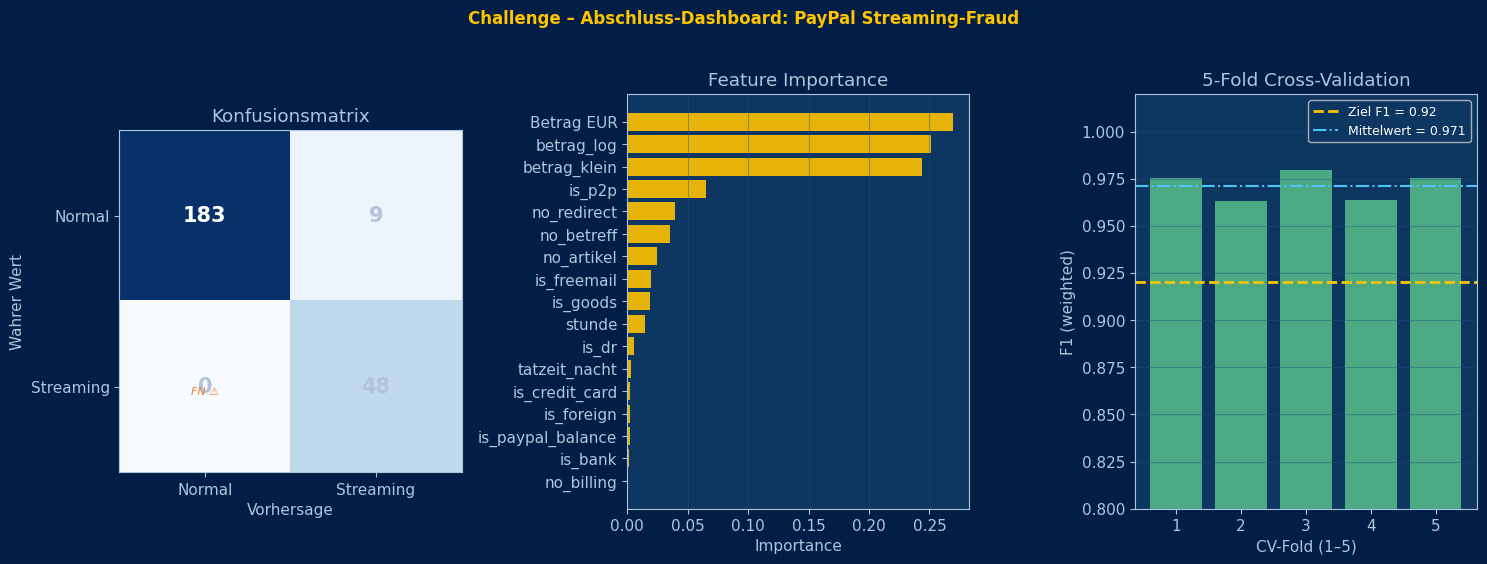


📝 Begründung der Modellwahl für den forensischen Einsatz:

   Random Forest mit class_weight="balanced" wurde gewählt, weil:
   ✓ Hoher Recall für Streaming — wenige Beweislücken
   ✓ Feature Importance dokumentierbar für Staatsanwaltschaft
   ✓ Robust ohne aufwendiges Tuning
   ✓ Erklärbar: "Transaktion als Streaming eingestuft wegen Betrag + P2P + kein Artikel"

   Wann XGBoost besser wäre:
   ✓ scale_pos_weight=4 für noch präziseres Handling des Ungleichgewichts
   ✓ Wenn SHAP-Einzelfall-Erklärungen für jeden Aktenvermerk benötigt werden

   ⚖️  Rechtlicher Hinweis: Das Modell ist ein Triage-Werkzeug.
      Jede als Streaming markierte Transaktion wird manuell von einem
      Ermittler geprüft. Das Modell ersetzt keine Ermittlungsarbeit.


In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# SCHRITT 6.2: Cross-Validation + Abschluss-Dashboard
# ─────────────────────────────────────────────────────────────────────────────

print('⏳ Cross-Validation läuft (5 Folds)...')
cv_scores = cross_val_score(
    best_model, X, y, cv=5, scoring='f1_weighted', n_jobs=-1
)

print(f'5-Fold Cross-Validation F1 (weighted):')
print(f'  Mittelwert: {cv_scores.mean():.3f}')
print(f'  Std.abw.:   ±{cv_scores.std():.3f}')
print(f'  Folds:      {[f"{s:.3f}" for s in cv_scores]}')
print()

# ── Abschluss-Dashboard ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5.5))
fig.suptitle('Challenge – Abschluss-Dashboard: PayPal Streaming-Fraud',
             fontsize=12, color=C['gold'], fontweight='bold', y=1.02)

# ── Panel 1: Konfusionsmatrix (2×2) ──────────────────────────────────────────
cm_best = confusion_matrix(y_te, y_pred_best)
im = axes[0].imshow(cm_best, cmap='Blues')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(KLASSEN)
axes[0].set_yticks([0, 1])
axes[0].set_yticklabels(KLASSEN)
axes[0].set_xlabel('Vorhersage')
axes[0].set_ylabel('Wahrer Wert')
axes[0].set_title('Konfusionsmatrix', color=C['lgray'])
for i in range(2):
    for j in range(2):
        count = cm_best[i, j]
        color = 'white' if count > cm_best.max() * 0.5 else C['lgray']
        axes[0].text(j, i, str(count), ha='center', va='center',
                     fontsize=15, fontweight='bold', color=color)
# FN markieren (unten links = Streaming als Normal übersehen)
axes[0].text(0, 1, 'FN ⚠️', ha='center', va='top',
             fontsize=8, color=C['orange'], style='italic')

# ── Panel 2: Feature Importance ───────────────────────────────────────────────
fi_best = best_model.feature_importances_
idx_b   = np.argsort(fi_best)[::-1]
axes[1].barh([FEAT[i] for i in idx_b][::-1],
             fi_best[idx_b][::-1], color=C['gold'], alpha=0.9)
axes[1].set_title('Feature Importance', color=C['lgray'])
axes[1].set_xlabel('Importance')
axes[1].grid(True, axis='x')

# ── Panel 3: 5-Fold Cross-Validation ─────────────────────────────────────────
bar_colors = [C['green'] if s >= 0.92 else C['orange'] for s in cv_scores]
axes[2].bar(range(1, 6), cv_scores, color=bar_colors, alpha=0.9)
axes[2].axhline(0.92, color=C['gold'],  lw=2, ls='--', label='Ziel F1 = 0.92')
axes[2].axhline(cv_scores.mean(), color=C['ice'], lw=1.5, ls='-.',
                label=f'Mittelwert = {cv_scores.mean():.3f}')
axes[2].set_xlabel('CV-Fold (1–5)')
axes[2].set_ylabel('F1 (weighted)')
axes[2].set_title('5-Fold Cross-Validation', color=C['lgray'])
axes[2].set_ylim(0.80, 1.02)
axes[2].legend(fontsize=9)
axes[2].grid(True, axis='y')

plt.tight_layout()
plt.show()

# ── Modellentscheidung ────────────────────────────────────────────────────────
print()
print('📝 Begründung der Modellwahl für den forensischen Einsatz:')
print()
print('   Random Forest mit class_weight="balanced" wurde gewählt, weil:')
print('   ✓ Hoher Recall für Streaming — wenige Beweislücken')
print('   ✓ Feature Importance dokumentierbar für Staatsanwaltschaft')
print('   ✓ Robust ohne aufwendiges Tuning')
print('   ✓ Erklärbar: "Transaktion als Streaming eingestuft wegen Betrag + P2P + kein Artikel"')
print()
print('   Wann XGBoost besser wäre:')
print('   ✓ scale_pos_weight=4 für noch präziseres Handling des Ungleichgewichts')
print('   ✓ Wenn SHAP-Einzelfall-Erklärungen für jeden Aktenvermerk benötigt werden')
print()
print('   ⚖️  Rechtlicher Hinweis: Das Modell ist ein Triage-Werkzeug.')
print('      Jede als Streaming markierte Transaktion wird manuell von einem')
print('      Ermittler geprüft. Das Modell ersetzt keine Ermittlungsarbeit.')


---
## 📋 Zusammenfassung

### Das haben wir gelernt

| Konzept | Was wir implementiert haben | Im forensischen Kontext |
|---------|---------------------------|------------------------|
| **Feature Engineering** | 17 Features aus PayPal-Rohdaten abgeleitet | Transaktionsmerkmale als Ermittlungshypothesen kodieren |
| **Random Forest** | 500 Bäume, class_weight='balanced' | Robuste Triage auch bei 80/20-Ungleichgewicht |
| **XGBoost** | Boosting mit logloss, scale_pos_weight | Präzises Lernen mit Fokus auf Minderheitsklasse |
| **ROC-AUC (binär)** | Direkt proba[:,1] für Klasse "Streaming" | Trade-off: Recall vs. Fehlalarme steuerbar |
| **Feature Importance** | Betrag, P2P, kein Artikel dominieren | Dokumentierbar für Aktenvermerk und Gericht |
| **SHAP** | Einzelfall-Erklärung für jede TX | „TX ist Streaming wegen Betrag + P2P + kein Artikel" |
| **Cross-Validation** | 5-Fold mit f1_weighted | Robuste Schätzung bei unbalancierten Klassen |

---

### 🔑 Die operative Kernfrage: Was bringt das Modell der Ermittlung?

> **Ohne Modell:** Ein Ermittler sichtet 1.200 Transaktionen manuell — mehrere Stunden,
> subjektiv, fehleranfällig.
>
> **Mit Modell:** Das Modell markiert ~240 TX als Streaming-verdächtig.
> Der Ermittler prüft nur diese — **80% Zeitersparnis**, dokumentierbare Kriterien,
> keine Beweislücken durch Übersehen.

> **Was das Modell nicht kann:** Neue Zahlungsmuster erkennen, die nicht im Training vorkamen
> (z.B. neue Tarnstrategie: höhere Beträge, legitime Artikelbezeichnungen).
> Das Modell braucht regelmäßiges Nachtraining mit neuen Falldaten.

---

### 🔑 Wann welches Modell?

| Situation | Empfehlung |
|-----------|------------|
| Tabellarische Transaktionsdaten, schneller Einsatz | **Random Forest + class_weight** |
| Maximale Präzision, Tuning-Zeit vorhanden | **XGBoost + scale_pos_weight** |
| Einzelfall-Erklärung für Staatsanwaltschaft | **XGBoost + SHAP** |
| Zeitreihen (Kontoentwicklung über Monate) | **LSTM oder XGBoost** |
| Kommunikationsinhalte (Chat-Analyse) | **Transformer** |

> **Merksatz:** Bei tabellarischen Transaktionsdaten schlagen Ensemble-Methoden
> neuronale Netze fast immer — und sind dabei erklärbarer.
> Das ist für forensische Anwendungen kein Nachteil, sondern ein Vorteil.

---

### 🏁 Nächste Schritte

| Notebook | Inhalt |
|----------|--------|
| **NB-04** (S2.1) | ML-Modellierung vertieft: Cross-Validation & Hyperparameter-Tuning |
| **NB-07** (S2.4) | RAG & Vektordatenbanken: Unsupervised Learning in der Praxis |
| **NB-09** (S3.1) | Deepfake-Erkennung mit CNN — wenn Ensemble nicht reicht |

---

> **KI Advanced · IA1017000 · Hochschule für Polizei Baden-Württemberg**
